# Laboratório 08: Discretização de Variáveis (Binning)
**Disciplina:** Extração e Preparação de Dados (IBM8915)
**Professor:** Luís Aramis

**Objetivo:** Aprender a transformar variáveis numéricas contínuas em variáveis categóricas (faixas ou "baldes"). Você entenderá na prática a diferença crítica entre cortes absolutos (`pd.cut`) e cortes baseados em quantis populacionais (`pd.qcut`) em dados com alta desigualdade.

In [ ]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

## Parte 1: Exemplo Guiado - A Ilusão do `cut` em Dados Desiguais
Abaixo, simularemos a distribuição de salários de uma empresa onde a grande maioria ganha pouco, e alguns poucos diretores ganham fortunas (distorção/cauda longa). 
Vamos tentar dividir essas pessoas em 4 faixas salariais (Quartis) usando o `cut` comum e depois a solução correta com `qcut`. Observe a contagem de pessoas em cada grupo!

In [3]:
np.random.seed(42)
# Gerando 950 salários normais e 50 salários de diretores (outliers)
salarios_normais = np.random.normal(3000, 800, 950)
salarios_diretoria = np.random.normal(25000, 5000, 50)
todos_salarios = np.append(salarios_normais, salarios_diretoria)

df_empresa = pd.DataFrame({'ID_Funcionario': range(1, 1001), 'Salario': todos_salarios})

# 1. A Abordagem Ingênua: Cortar em 4 pedaços matemáticos iguais (cut)
df_empresa['Faixa_Cut'] = pd.cut(df_empresa['Salario'], bins=4, labels=['Baixo', 'Médio', 'Alto', 'Diretoria'])

print("--- Distribuição com CUT (Corte Absoluto) ---")
print(df_empresa['Faixa_Cut'].value_counts())
print("\nProblema: Quase todo mundo caiu no balde 'Baixo', e os outros ficaram vazios. A máquina não aprende assim.")

# 2. A Abordagem Inteligente: Cortar a população em 4 pedaços de mesmo tamanho (qcut)
df_empresa['Faixa_Qcut'] = pd.qcut(df_empresa['Salario'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

print("\n--- Distribuição com QCUT (Quantis) ---")
print(df_empresa['Faixa_Qcut'].value_counts())
print("\nSolução: O qcut garantiu exatamente 250 pessoas em cada balde, balanceando os dados perfeitamente!")

--- Distribuição com CUT (Corte Absoluto) ---
Faixa_Cut
Baixo        950
Diretoria     24
Alto          22
Médio          4
Name: count, dtype: int64

Problema: Quase todo mundo caiu no balde 'Baixo', e os outros ficaram vazios. A máquina não aprende assim.

--- Distribuição com QCUT (Quantis) ---
Faixa_Qcut
Q1    250
Q2    250
Q3    250
Q4    250
Name: count, dtype: int64

Solução: O qcut garantiu exatamente 250 pessoas em cada balde, balanceando os dados perfeitamente!


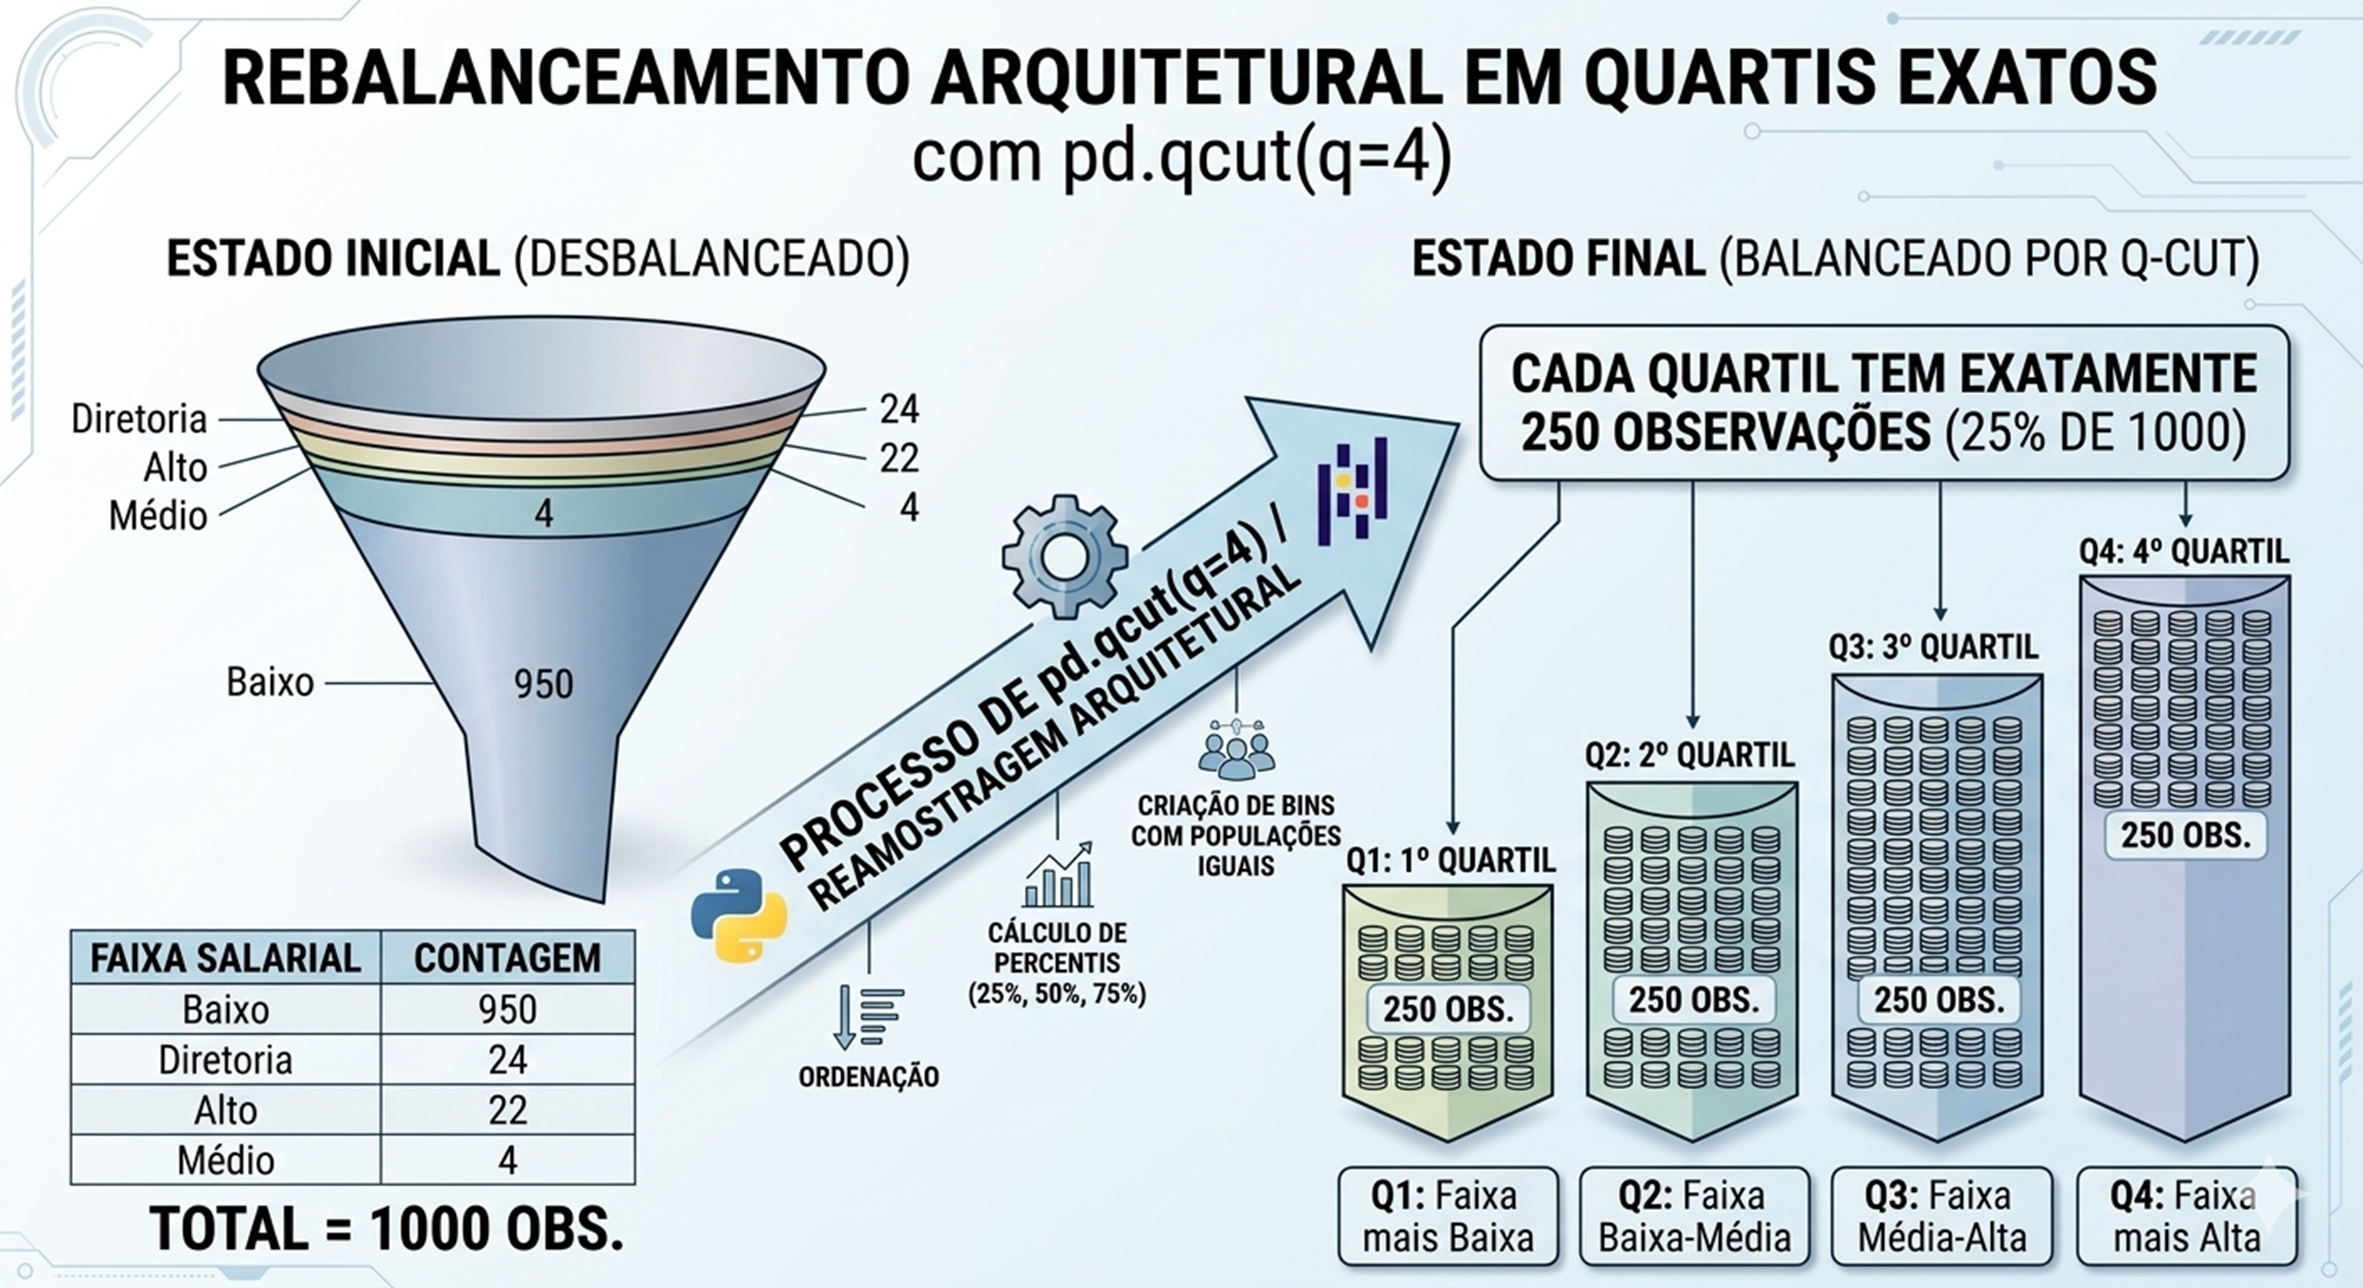

## Parte 2: Exercício Prático (Mão na Massa)
Você trabalha no setor de Marketing de um e-commerce. A equipe de vendas pediu para você segmentar a base de clientes de acordo com a `Idade`, pois eles farão 3 campanhas de e-mail marketing diferentes.

A regra de negócio (matemática) exigida pelo marketing é estrita:
* **Jovem:** De 0 até menores de 25 anos `[0, 25)`
* **Adulto:** De 25 até menores de 60 anos `[25, 60)`
* **Sênior:** De 60 anos em diante `[60, infinito)`

**Sua Tarefa:**
1. Crie uma lista com os limites (`bins`) descritos acima. *Dica: Use `np.inf` para o limite final.*
2. Crie uma lista com os `labels` (Jovem, Adulto, Sênior).
3. Use a função `pd.cut` (com o parâmetro `right=False` para garantir que alguém com 25 anos exatos caia na faixa 'Adulto').
4. Salve o resultado na coluna `Segmento_Marketing` e exiba o resultado.

In [ ]:
# NÃO ALTERE ESTE CÓDIGO - Geração do cenário do exercício
np.random.seed(10)
df_clientes = pd.DataFrame({
    'ID_Cliente': range(100, 120),
    'Idade': np.random.randint(16, 85, 20)
})
display(df_clientes.head())

In [ ]:
# Passo 1: Defina as fronteiras (bins)
df_clientes['Segmento marketing'] = pd.cut(df_empresa['Idade'], bins=[25,60,np.inf], labels=['Jovem', 'Adulto', 'Idoso'])
df_clientes.value_counts()

---
## Parte 3: Desafio para Casa - O Analista de Risco
Este desafio consolida as **Aulas 04, 07 e 09**. 
Imagine que você está processando dados para um modelo de concessão de Crédito Bancário.

**A Missão:**
1. Execute a célula abaixo para gerar os dados (`df_banco`). Note que existem valores nulos na coluna contínua `Renda`.
2. **(Aula 07):** Preencha os valores ausentes (`fillna`) da coluna `Renda` usando a **Mediana**.
3. **(Aula 09/Hoje):** Você não pode usar a Renda contínua no modelo porque ela é muito distorcida. Crie uma nova coluna chamada `Classe_Social` dividindo a `Renda` em **5 quantis iguais** usando `pd.qcut()`. Nomeie os labels como `['Classe E', 'Classe D', 'Classe C', 'Classe B', 'Classe A']`.
4. **(Aula 04):** Usando o `groupby`, calcule a **Média de Calote** (`Risco_Calote`) para cada `Classe_Social`. As classes mais baixas realmente dão mais calote neste nosso dataset simulado?

In [ ]:
# NÃO ALTERE ESTE CÓDIGO - Simulador de Risco Bancário
np.random.seed(42)
n_linhas = 1000

renda_base = np.random.exponential(scale=3000, size=n_linhas) + 1000 # Cauda longa

df_banco = pd.DataFrame({
    'ID_Conta': range(1, n_linhas + 1),
    'Renda': renda_base,
    'Risco_Calote': np.where(renda_base < 3000, np.random.choice([0, 1], n_linhas, p=[0.6, 0.4]), 
                             np.random.choice([0, 1], n_linhas, p=[0.9, 0.1])) 
})

# Inserindo buracos (NaNs) na Renda
df_banco.loc[np.random.choice(n_linhas, 80, replace=False), 'Renda'] = np.nan

In [ ]:
# ESCREVA SEU CÓDIGO AQUI

# 1. Tratamento Univariado: Preencher nulos da 'Renda' com a mediana (.median())


# 2. Discretização Democrática: Criar 'Classe_Social' usando pd.qcut (q=5) com labels


# 3. Análise Exploratória Final: Groupby da média de 'Risco_Calote' por 'Classe_Social'


